# Computer Vision with OpenCV and Deep Learning - Goruntu Isleme

In [2]:
#pip install bing-image-downloader

In [3]:
from bing_image_downloader import downloader

In [5]:
downloader.download('cat', limit=100)

[%] Downloading Images to /Users/zaidahmed/Desktop/Yapay-Zeka-Kursu/day5/dataset/cat


[!!] Indexing page: 1

[%] Indexed 13 Images on Page 1.


[%] Downloading Image #1 from https://www.bubblypet.com/wp-content/uploads/2022/12/Orange-and-white-cat-breed-sitting-on-the-street.jpg
[%] File Downloaded!

[%] Downloading Image #2 from http://www.publicdomainpictures.net/pictures/50000/velka/kitty-cat-1374676578uQX.jpg
[%] File Downloaded!

[%] Downloading Image #3 from http://www.publicdomainpictures.net/pictures/90000/velka/ginger-cat-14011197866ER.jpg
[%] File Downloaded!

[%] Downloading Image #4 from http://www.publicdomainpictures.net/pictures/40000/velka/cat-1361104159nZ4.jpg
[!] Issue getting: http://www.publicdomainpictures.net/pictures/40000/velka/cat-1361104159nZ4.jpg
[!] Error:: [Errno 54] Connection reset by peer
[%] Downloading Image #4 from https://image.son-video.com/images/dynamic/Amplificateurs/articles/Yamaha/YAMRN301SI/Yamaha-R-N301-Silver_P_600.jpg
[%] File Downloaded!


In [6]:
import tensorflow as tf

2026-05-24 21:34:51.597336: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
mnist = tf.keras.datasets.mnist

In [8]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [9]:
x_train.shape

(60000, 28, 28)

In [10]:
import matplotlib.pyplot as plt

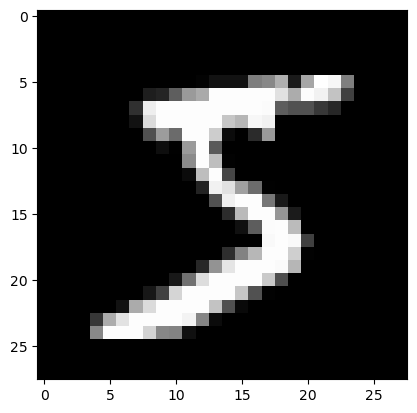

In [11]:
plt.imshow(x_train[0], cmap='gray')

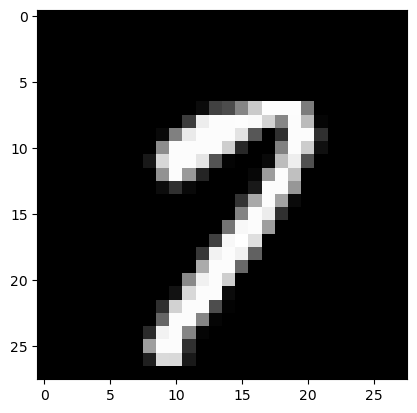

In [13]:
plt.imshow(x_train[9999], cmap='gray')

In [16]:
y_train[9999]

7

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9315 - loss: 0.2541 - val_accuracy: 0.9735 - val_loss: 0.1000
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9728 - loss: 0.0948 - val_accuracy: 0.9782 - val_loss: 0.0717
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9790 - loss: 0.0724 - val_accuracy: 0.9820 - val_loss: 0.0670
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9825 - loss: 0.0609 - val_accuracy: 0.9832 - val_loss: 0.0643
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9838 - loss: 0.0538 - val_accuracy: 0.9843 - val_loss: 0.0604
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9857 - loss: 0.0481 - val_accuracy: 0.9825 - val_loss: 0.0621
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9867 - loss: 0.0434 - val_accuracy: 0.9853 - val_loss: 0.0601
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9880 -

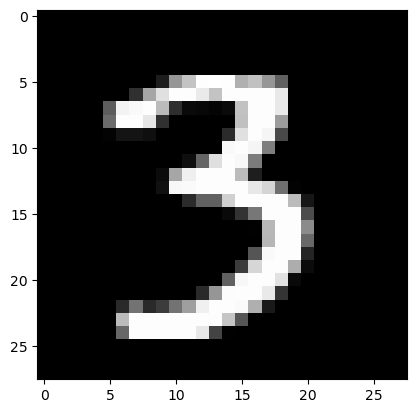

In [17]:
import tensorflow as tf

mnist=tf.keras.datasets.mnist

(train_images,train_labels),(test_images,test_labels)=mnist.load_data()

train_images.shape

import matplotlib.pyplot as plt

plt.imshow(train_images[0],cmap='gray')

plt.imshow(train_images[10000],cmap='gray')

train_images=train_images/255.0
test_images=test_images/255.0

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, InputLayer, Reshape, MaxPooling2D, Flatten, Dropout, BatchNormalization

model=Sequential()
model.add(InputLayer(input_shape=(28,28)))
model.add(Reshape(target_shape=(28,28,1)))
model.add(Conv2D(filters=12,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(10)) # 10 fakli cevap classification 0-9 a kadar olan rakamlar
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

model.fit(train_images,train_labels, validation_split=.10, epochs=10)

loss,accuracy=model.evaluate(test_images,test_labels)

accuracy

model.save('benimmodel.h5')


In [19]:
import numpy as np

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


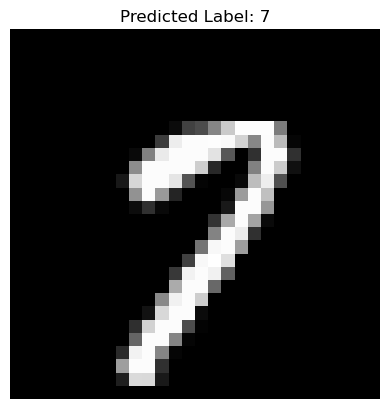

In [23]:
index = 9999  # Change this to the index of the image you want to predict
image = train_images[index].reshape(1, 28, 28)  # Reshaping for prediction
predicted_class = model.predict(image)
predicted_label = np.argmax(predicted_class)
# Visualize the image and result
plt.imshow(train_images[index], cmap='gray')
plt.title(f'Predicted Label: {predicted_label}')
plt.axis('off')
plt.show()